# iOS Reviews — Recent Period Deep Dive (Last 6 Months)
Focused analysis on Dec 2025 – May 2026 with month-by-month trends.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import re
from collections import Counter
from wordcloud import WordCloud
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

STOP_WORDS = set(stopwords.words('english'))
EXTRA_STOP = {'app', 'tira', 'ok', 'use', 'one', 'also', 'get', 'even', 'like',
              'just', 'time', 'please', 'give', 'nice', 'would', 'make', 'much',
              'many', 'good', 'great', 'love', 'really', 'using', 'better', 'best',
              'worst', 'need', 'used', 'well', 'still', 'us', 'take', 'every',
              'want', 'able', 'way', 'never', 'always', 'back', 'go', 'going',
              'come', 'try', 'show', 'will', 'cant', 'dont', 'im', 'ive', 'its',
              'na', 'ka', 'hai', 'nahi', 'bahut', 'aur', 'bad', 'very', 'see'}
ALL_STOP = STOP_WORDS | EXTRA_STOP

THEMES = {
    'Order / Returns':          ['order', 'return', 'exchange', 'cancel', 'cancelled', 'replacement', 'missing'],
    'Product Quality':          ['product', 'quality', 'original', 'fake', 'genuine', 'brand', 'item', 'broken', 'damaged', 'wrong', 'expired'],
    'Delivery / Shipping':      ['delivery', 'ship', 'shipping', 'deliver', 'courier', 'dispatch', 'arrive', 'arrived', 'late', 'delay', 'delayed'],
    'Customer Support':         ['support', 'service', 'customer', 'help', 'response', 'team', 'complaint', 'helpline', 'contact', 'chat', 'call'],
    'Payment / Refund':         ['payment', 'refund', 'cashback', 'money', 'pay', 'paid', 'transaction', 'wallet', 'coupon', 'discount', 'offer'],
    'App Performance':          ['crash', 'hang', 'slow', 'bug', 'error', 'loading', 'load', 'freeze', 'glitch', 'issue', 'problem', 'lag'],
    'UI / User Experience':     ['interface', 'design', 'experience', 'easy', 'difficult', 'navigate', 'search', 'filter', 'layout', 'simple', 'confusing'],
    'Pincode / Availability':   ['pincode', 'pin code', 'area', 'location', 'available', 'unavailable', 'serviceable', 'city', 'zone'],
    'Login / Account':          ['login', 'otp', 'account', 'sign', 'password', 'verify', 'register', 'logout'],
    'Offers / Discounts':       ['offer', 'sale', 'discount', 'coupon', 'deal', 'promo', 'cashback', 'reward', 'point', 'points'],
}

SENT_COLORS = {'Positive': '#2ca02c', 'Neutral': '#bcbd22', 'Negative': '#d62728'}
RATING_COLORS = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4']

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return ' '.join([w for w in text.split() if w not in ALL_STOP and len(w) > 2])

def assign_sentiment(r):
    return 'Negative' if r <= 2 else 'Neutral' if r == 3 else 'Positive'

def detect_themes(text):
    t = str(text).lower()
    matched = [th for th, kws in THEMES.items() if any(k in t for k in kws)]
    return matched if matched else ['Other']

print('Setup complete.')

/Users/shubham.bansla/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Setup complete.


## 1. Load & Filter Recent Period

In [2]:
df_all = pd.read_csv('ios_reviews.csv').dropna(subset=['body','rating','created_date'])
df_all['body'] = df_all['body'].astype(str).str.strip()
df_all = df_all[df_all['body'].str.len() > 1]
df_all['rating'] = df_all['rating'].astype(int)
df_all['created_date'] = pd.to_datetime(df_all['created_date'], utc=True)
df_all['year_month'] = df_all['created_date'].dt.to_period('M').astype(str)
df_all['sentiment'] = df_all['rating'].apply(assign_sentiment)
df_all['clean_body'] = df_all['body'].apply(clean_text)
df_all['word_count'] = df_all['body'].str.split().str.len()
df_all['polarity'] = df_all['body'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_all['themes'] = df_all['body'].apply(detect_themes)

# Recent = last 6 months by date
cutoff = df_all['created_date'].max() - pd.DateOffset(months=6)
df = df_all[df_all['created_date'] >= cutoff].copy()
latest_month = df_all['year_month'].max()
prev_month   = sorted(df_all['year_month'].unique())[-2]

sc_all = df_all['sentiment'].value_counts()
sc_rec = df['sentiment'].value_counts()
sp_all = (sc_all/len(df_all)*100).round(1)
sp_rec = (sc_rec/len(df)*100).round(1)

print(f'All-time reviews  : {len(df_all):,}')
print(f'Recent period     : {df["created_date"].min().date()} to {df["created_date"].max().date()}')
print(f'Recent reviews    : {len(df):,} across {df["year_month"].nunique()} months')
print(f'Latest month      : {latest_month} ({len(df[df["year_month"]==latest_month])} reviews)')
print(f'\nRecent Sentiment:')
for s in ['Positive','Neutral','Negative']:
    print(f'  {s:<10}: {sc_rec.get(s,0):>4} ({sp_rec.get(s,0):.1f}%)  |  All-time: {sp_all.get(s,0):.1f}%')
print(f'  Avg Rating: {df["rating"].mean():.2f}  |  All-time: {df_all["rating"].mean():.2f}')

All-time reviews  : 1,482
Recent period     : 2025-11-21 to 2026-05-18
Recent reviews    : 351 across 7 months
Latest month      : 2026-05 (39 reviews)

Recent Sentiment:
  Positive  :  103 (29.3%)  |  All-time: 21.7%
  Neutral   :    7 (2.0%)  |  All-time: 2.8%
  Negative  :  241 (68.7%)  |  All-time: 75.5%
  Avg Rating: 2.21  |  All-time: 1.94


## 2. Month-by-Month Trend (Recent Period)

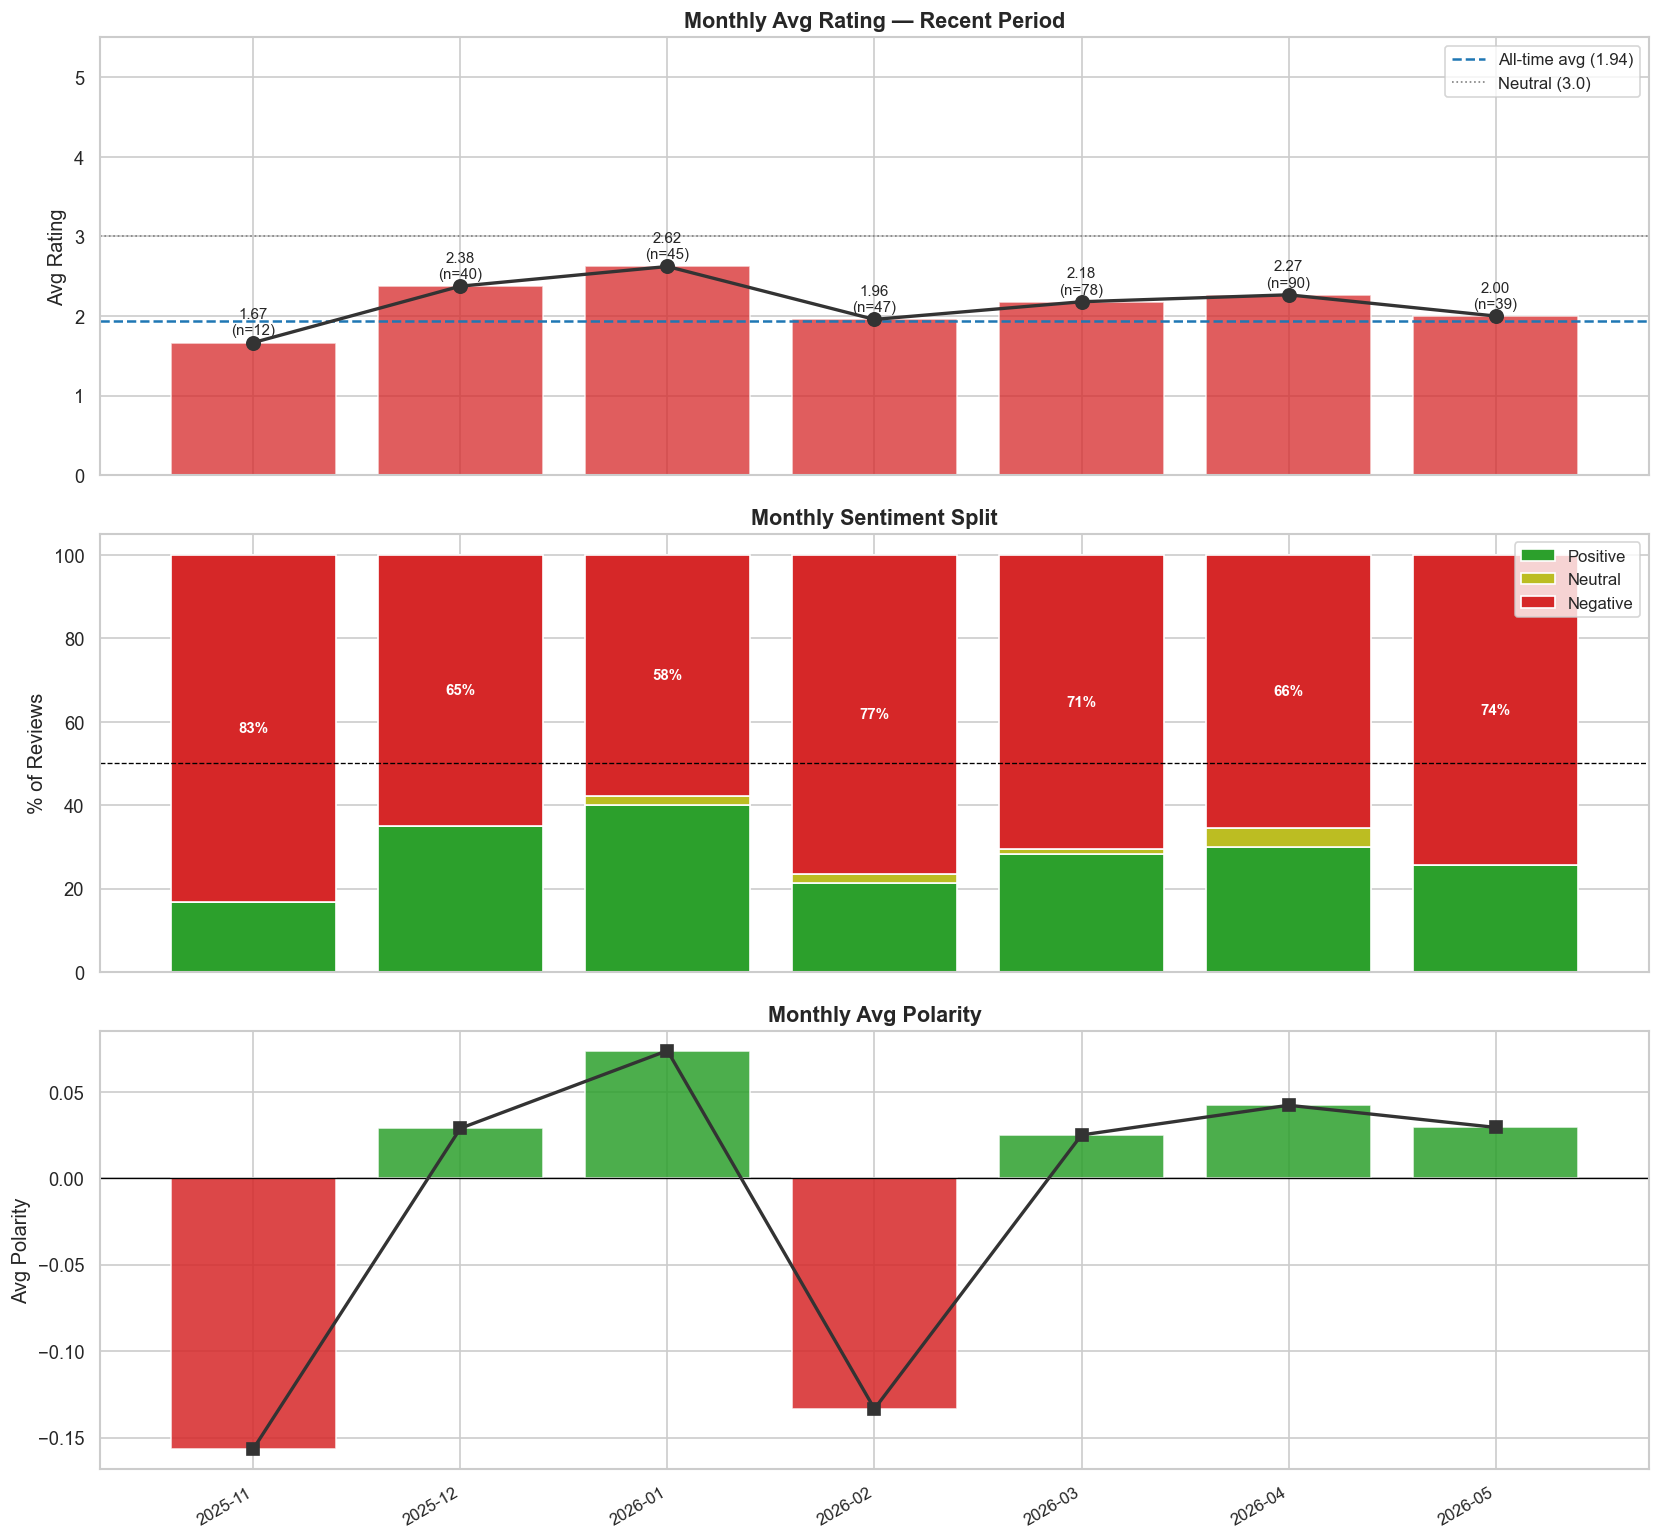

year_month  count  avg_rating   pct_pos   pct_neg
   2025-11     12    1.666667 16.666667 83.333333
   2025-12     40    2.375000 35.000000 65.000000
   2026-01     45    2.622222 40.000000 57.777778
   2026-02     47    1.957447 21.276596 76.595745
   2026-03     78    2.179487 28.205128 70.512821
   2026-04     90    2.266667 30.000000 65.555556
   2026-05     39    2.000000 25.641026 74.358974


In [3]:
monthly = df.groupby('year_month').agg(
    count       =('rating','count'),
    avg_rating  =('rating','mean'),
    avg_polarity=('polarity','mean'),
    pct_pos     =('sentiment', lambda x: (x=='Positive').mean()*100),
    pct_neg     =('sentiment', lambda x: (x=='Negative').mean()*100),
    pct_neu     =('sentiment', lambda x: (x=='Neutral').mean()*100),
).reset_index().sort_values('year_month').reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)
x = range(len(monthly))
xlabels = monthly['year_month'].tolist()

# Avg rating
bc = ['#2ca02c' if r>=4 else '#ff7f0e' if r>=3 else '#d62728' for r in monthly['avg_rating']]
axes[0].bar(x, monthly['avg_rating'], color=bc, edgecolor='white', alpha=0.75)
axes[0].plot(x, monthly['avg_rating'], 'o-', color='#333', linewidth=2, markersize=8, zorder=5)
axes[0].axhline(df_all['rating'].mean(), color='#1f77b4', linestyle='--', linewidth=1.5, label=f'All-time avg ({df_all["rating"].mean():.2f})')
axes[0].axhline(3, color='gray', linestyle=':', linewidth=1, label='Neutral (3.0)')
axes[0].set_ylim(0, 5.5); axes[0].set_ylabel('Avg Rating', fontsize=12)
axes[0].set_title('Monthly Avg Rating — Recent Period', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
for xi, (_, row) in zip(x, monthly.iterrows()):
    axes[0].text(xi, row['avg_rating']+0.1, f"{row['avg_rating']:.2f}\n(n={int(row['count'])})",
                 ha='center', fontsize=9)

# Stacked sentiment
axes[1].bar(x, monthly['pct_pos'], label='Positive', color='#2ca02c', edgecolor='white')
axes[1].bar(x, monthly['pct_neu'], bottom=monthly['pct_pos'], label='Neutral', color='#bcbd22', edgecolor='white')
axes[1].bar(x, monthly['pct_neg'], bottom=monthly['pct_pos']+monthly['pct_neu'], label='Negative', color='#d62728', edgecolor='white')
axes[1].axhline(50, color='black', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('% of Reviews', fontsize=12)
axes[1].set_title('Monthly Sentiment Split', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10, loc='upper right')
for xi, (_, row) in zip(x, monthly.iterrows()):
    axes[1].text(xi, row['pct_neg']/2 + row['pct_pos'] + row['pct_neu'],
                 f"{row['pct_neg']:.0f}%", ha='center', va='center', fontsize=9, color='white', fontweight='bold')

# Polarity
pc = ['#2ca02c' if p>=0 else '#d62728' for p in monthly['avg_polarity']]
axes[2].bar(x, monthly['avg_polarity'], color=pc, edgecolor='white', alpha=0.85)
axes[2].plot(x, monthly['avg_polarity'], 's-', color='#333', linewidth=2, markersize=7, zorder=5)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_ylabel('Avg Polarity', fontsize=12)
axes[2].set_title('Monthly Avg Polarity', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xticks(list(x))
    ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=10)

plt.tight_layout()
plt.savefig('r01_monthly_trend.png', bbox_inches='tight')
plt.show()

print(monthly[['year_month','count','avg_rating','pct_pos','pct_neg']].to_string(index=False))

## 3. Latest Month vs Previous Month

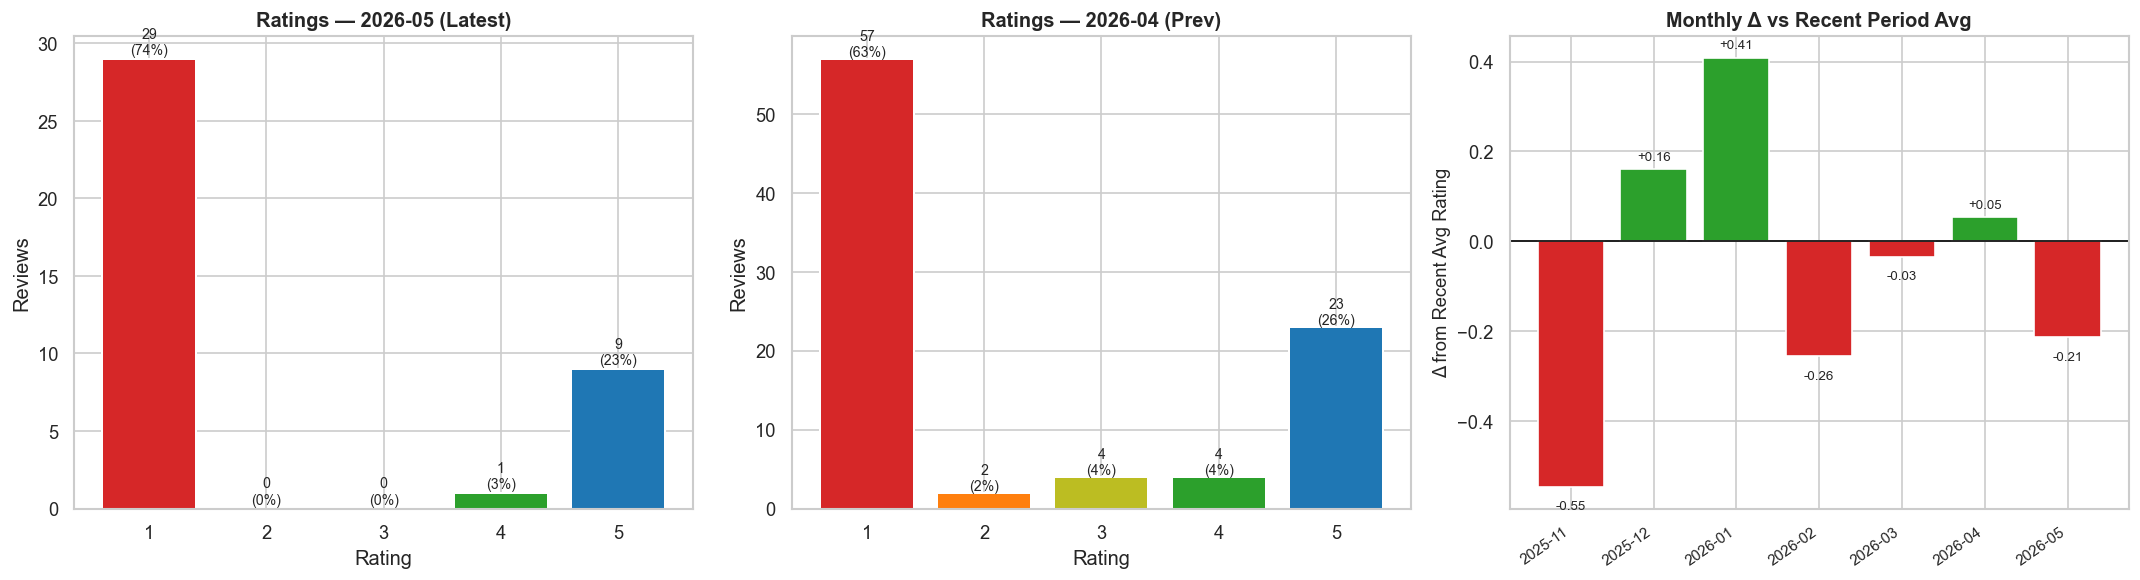

2026-05: 39 reviews | avg 2.00 | pos 26% | neg 74%
2026-04: 90 reviews | avg 2.27 | pos 30% | neg 66%


In [4]:
latest_df = df_all[df_all['year_month'] == latest_month].copy()
prev_df   = df_all[df_all['year_month'] == prev_month].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (vdf, label) in enumerate([(latest_df, f'{latest_month} (Latest)'), (prev_df, f'{prev_month} (Prev)')]):
    rc = vdf['rating'].value_counts().sort_index().reindex([1,2,3,4,5], fill_value=0)
    axes[i].bar(rc.index, rc.values, color=RATING_COLORS, edgecolor='white', linewidth=1.2)
    axes[i].set_title(f'Ratings — {label}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Rating'); axes[i].set_ylabel('Reviews')
    axes[i].set_xticks([1,2,3,4,5])
    for r, v in zip(rc.index, rc.values):
        axes[i].text(r, v+0.3, f'{v}\n({v/len(vdf)*100:.0f}%)', ha='center', fontsize=8.5)

# Delta vs recent period avg
rec_avg = df['rating'].mean()
delta = monthly.copy()
delta['delta'] = delta['avg_rating'] - rec_avg
dc = ['#2ca02c' if d>=0 else '#d62728' for d in delta['delta']]
axes[2].bar(range(len(delta)), delta['delta'], color=dc, edgecolor='white')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_xticks(range(len(delta)))
axes[2].set_xticklabels(delta['year_month'].tolist(), rotation=35, ha='right', fontsize=9)
axes[2].set_ylabel('Δ from Recent Avg Rating', fontsize=11)
axes[2].set_title('Monthly Δ vs Recent Period Avg', fontsize=12, fontweight='bold')
for xi, (_, row) in enumerate(delta.iterrows()):
    axes[2].text(xi, row['delta']+(0.02 if row['delta']>=0 else -0.05),
                 f"{row['delta']:+.2f}", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('r02_month_comparison.png', bbox_inches='tight')
plt.show()

for vdf, label in [(latest_df, latest_month), (prev_df, prev_month)]:
    sc_v = vdf['sentiment'].value_counts()
    sp_v = (sc_v/len(vdf)*100).round(1)
    print(f'{label}: {len(vdf)} reviews | avg {vdf["rating"].mean():.2f} | pos {sp_v.get("Positive",0):.0f}% | neg {sp_v.get("Negative",0):.0f}%')

## 4. Theme Analysis — Recent Period

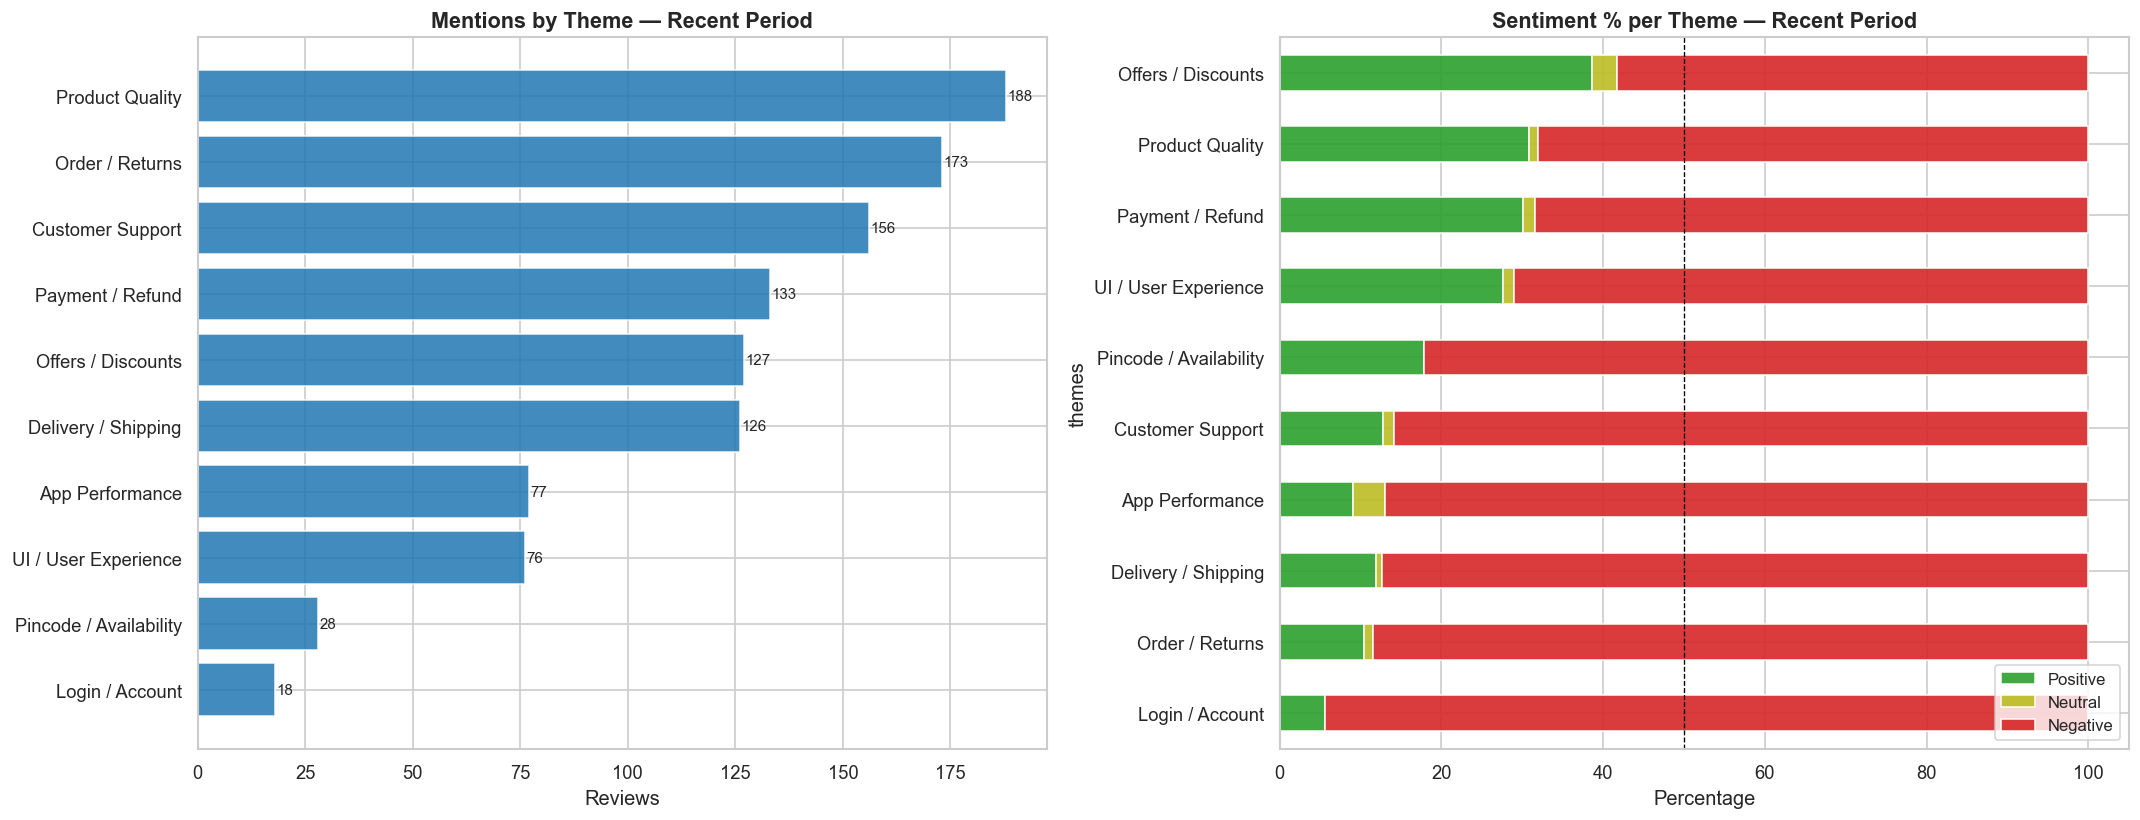

In [5]:
theme_df = df.explode('themes')
theme_sent = theme_df.groupby(['themes','sentiment']).size().unstack(fill_value=0)
for col in ['Positive','Neutral','Negative']:
    if col not in theme_sent.columns: theme_sent[col] = 0
theme_sent['total'] = theme_sent[['Positive','Neutral','Negative']].sum(axis=1)
theme_sent = theme_sent.sort_values('total', ascending=False)
theme_norm = theme_sent[['Positive','Neutral','Negative']].div(theme_sent['total'], axis=0)*100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plot_t = theme_sent[theme_sent.index != 'Other'].sort_values('total', ascending=True)
axes[0].barh(plot_t.index, plot_t['total'], color='#1f77b4', edgecolor='white', alpha=0.85)
axes[0].set_title('Mentions by Theme — Recent Period', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Reviews')
for i,(idx,row) in enumerate(plot_t.iterrows()):
    axes[0].text(row['total']+0.3, i, str(int(row['total'])), va='center', fontsize=9)

plot_n = theme_norm.drop('Other', errors='ignore').sort_values('Negative', ascending=False)
plot_n[['Positive','Neutral','Negative']].plot(
    kind='barh', stacked=True, ax=axes[1],
    color=['#2ca02c','#bcbd22','#d62728'], edgecolor='white', alpha=0.9)
axes[1].set_title('Sentiment % per Theme — Recent Period', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Percentage')
axes[1].axvline(50, color='black', linewidth=0.8, linestyle='--')
axes[1].legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('r03_recent_themes.png', bbox_inches='tight')
plt.show()

## 5. Pain Point Trends Month-by-Month

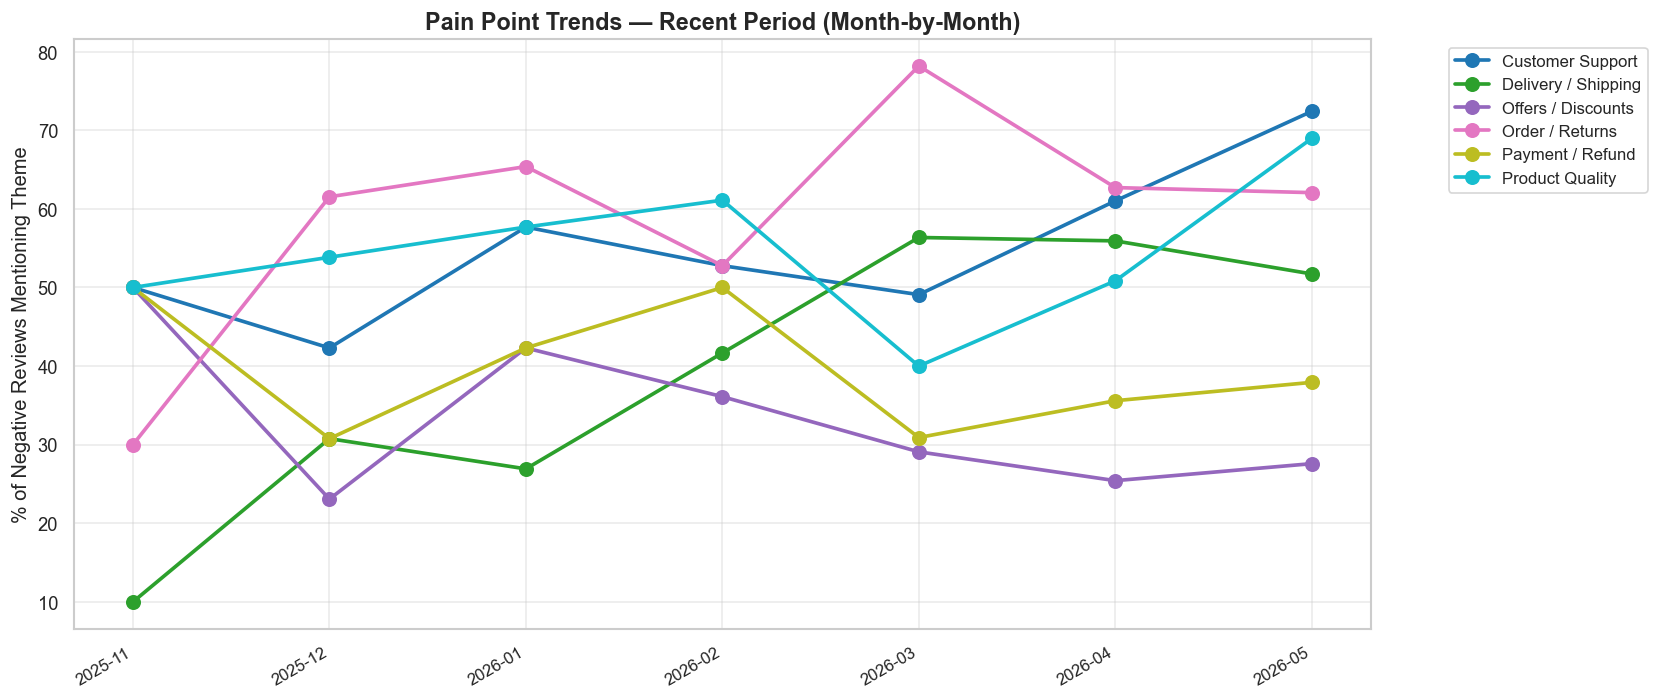

Pain point % per month (negative reviews):
year_month           2025-11  2025-12  2026-01  2026-02  2026-03  2026-04  2026-05
themes                                                                            
Customer Support        50.0     42.3     57.7     52.8     49.1     61.0     72.4
Delivery / Shipping     10.0     30.8     26.9     41.7     56.4     55.9     51.7
Offers / Discounts      50.0     23.1     42.3     36.1     29.1     25.4     27.6
Order / Returns         30.0     61.5     65.4     52.8     78.2     62.7     62.1
Payment / Refund        50.0     30.8     42.3     50.0     30.9     35.6     37.9
Product Quality         50.0     53.8     57.7     61.1     40.0     50.8     69.0


In [6]:
neg_recent = df[df['sentiment']=='Negative'].copy()
neg_theme_df = neg_recent.explode('themes')
neg_theme_df = neg_theme_df[neg_theme_df['themes'] != 'Other']

neg_pivot = neg_theme_df.groupby(['themes','year_month']).size().unstack(fill_value=0)
neg_count_per_month = neg_recent.groupby('year_month').size()
neg_pivot_pct = neg_pivot.div(neg_count_per_month, axis=1)*100

top_themes = neg_theme_df['themes'].value_counts().head(6).index.tolist()
neg_pivot_pct = neg_pivot_pct.loc[neg_pivot_pct.index.isin(top_themes)]
month_cols = sorted(neg_pivot_pct.columns.tolist())
neg_pivot_pct = neg_pivot_pct[month_cols]

fig, ax = plt.subplots(figsize=(14, 6))
colors_t = plt.cm.tab10(np.linspace(0, 1, len(top_themes)))
for theme, color in zip(neg_pivot_pct.index, colors_t):
    ax.plot(range(len(month_cols)), neg_pivot_pct.loc[theme, month_cols],
            marker='o', linewidth=2.2, label=theme, color=color, markersize=8)

ax.set_xticks(range(len(month_cols)))
ax.set_xticklabels(month_cols, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('% of Negative Reviews Mentioning Theme', fontsize=12)
ax.set_title('Pain Point Trends — Recent Period (Month-by-Month)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10, bbox_to_anchor=(1.22, 1))
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('r04_pain_point_trends.png', bbox_inches='tight')
plt.show()

print('Pain point % per month (negative reviews):')
print(neg_pivot_pct.round(1).to_string())

## 6. Latest Month Deep Dive

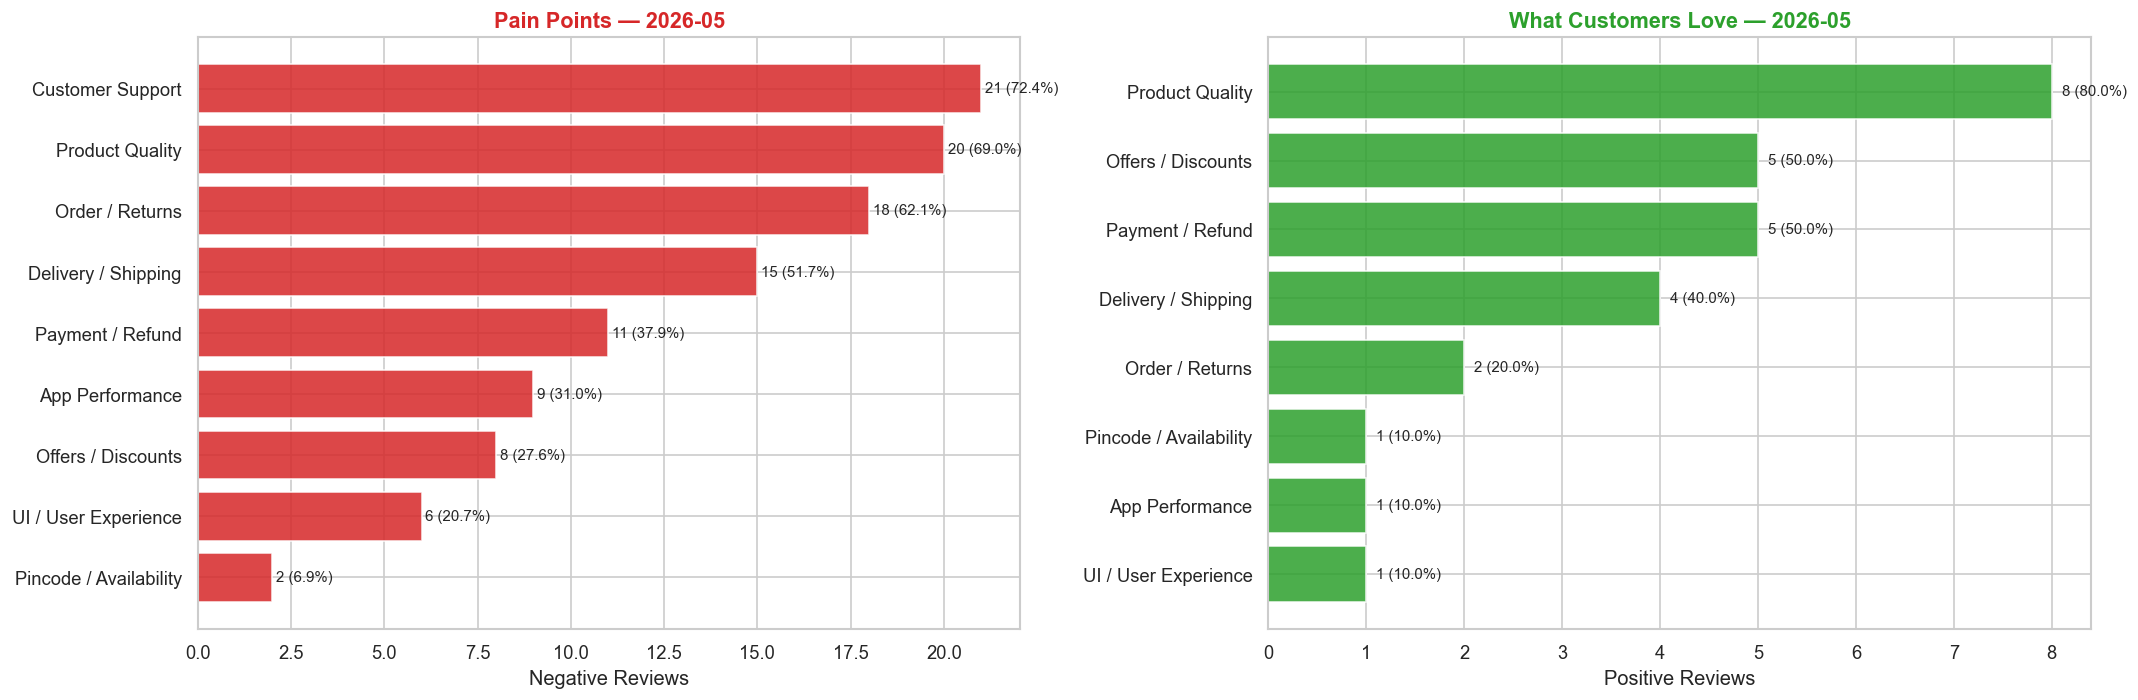

2026-05: 39 reviews | avg 2.00 | pos 25.6% | neg 74.4%


In [7]:
lat_neg = latest_df[latest_df['sentiment']=='Negative']
lat_pos = latest_df[latest_df['sentiment']=='Positive']

neg_tc = lat_neg.explode('themes')['themes'].value_counts()
pos_tc = lat_pos.explode('themes')['themes'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

nc_s = neg_tc[neg_tc.index!='Other'].sort_values(ascending=True)
axes[0].barh(nc_s.index, nc_s.values, color='#d62728', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Pain Points — {latest_month}', fontsize=13, fontweight='bold', color='#d62728')
axes[0].set_xlabel('Negative Reviews')
for i,(t,v) in enumerate(nc_s.items()):
    axes[0].text(v+0.1, i, f'{v} ({v/max(len(lat_neg),1)*100:.1f}%)', va='center', fontsize=9)

pc_s = pos_tc[pos_tc.index!='Other'].sort_values(ascending=True)
axes[1].barh(pc_s.index, pc_s.values, color='#2ca02c', edgecolor='white', alpha=0.85)
axes[1].set_title(f'What Customers Love — {latest_month}', fontsize=13, fontweight='bold', color='#2ca02c')
axes[1].set_xlabel('Positive Reviews')
for i,(t,v) in enumerate(pc_s.items()):
    axes[1].text(v+0.1, i, f'{v} ({v/max(len(lat_pos),1)*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('r05_latest_month_themes.png', bbox_inches='tight')
plt.show()

sc_lat = latest_df['sentiment'].value_counts()
sp_lat = (sc_lat/len(latest_df)*100).round(1)
print(f'{latest_month}: {len(latest_df)} reviews | avg {latest_df["rating"].mean():.2f} | pos {sp_lat.get("Positive",0):.1f}% | neg {sp_lat.get("Negative",0):.1f}%')

## 7. Word Clouds — Latest Month

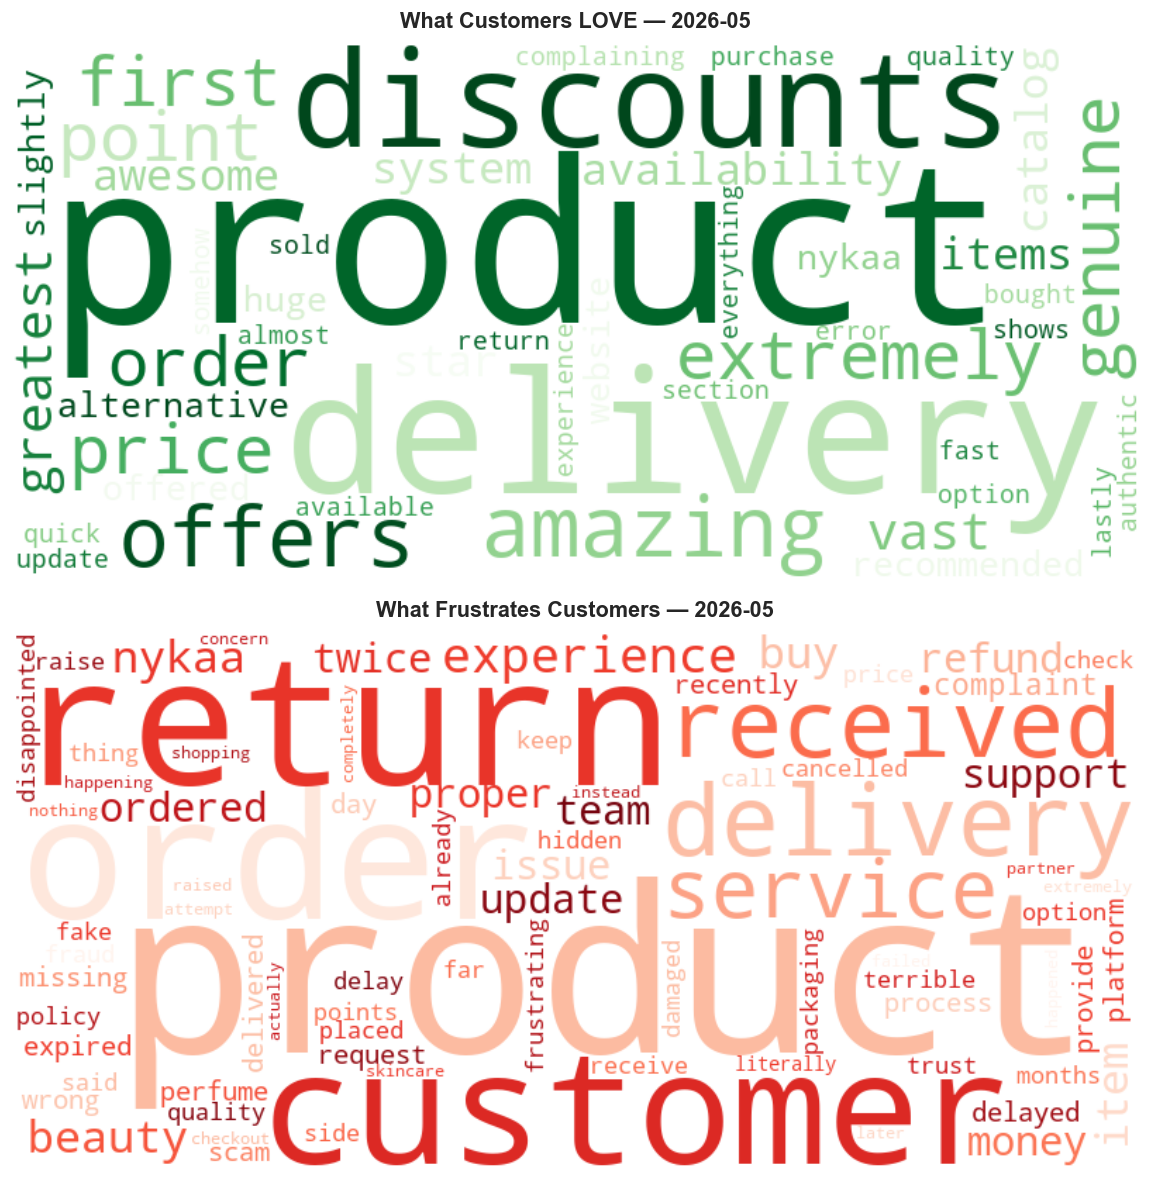

In [8]:
def make_wc(text, colormap, title, ax):
    wc = WordCloud(width=800, height=380, background_color='white',
                   colormap=colormap, max_words=80, collocations=False,
                   min_font_size=8).generate(text if text.strip() else 'no text')
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
make_wc(' '.join(lat_pos['clean_body']), 'Greens', f'What Customers LOVE — {latest_month}', axes[0])
make_wc(' '.join(lat_neg['clean_body']), 'Reds',   f'What Frustrates Customers — {latest_month}', axes[1])
plt.tight_layout()
plt.savefig('r06_latest_wordclouds.png', bbox_inches='tight')
plt.show()

## 8. TF-IDF — Latest Month Distinctive Phrases

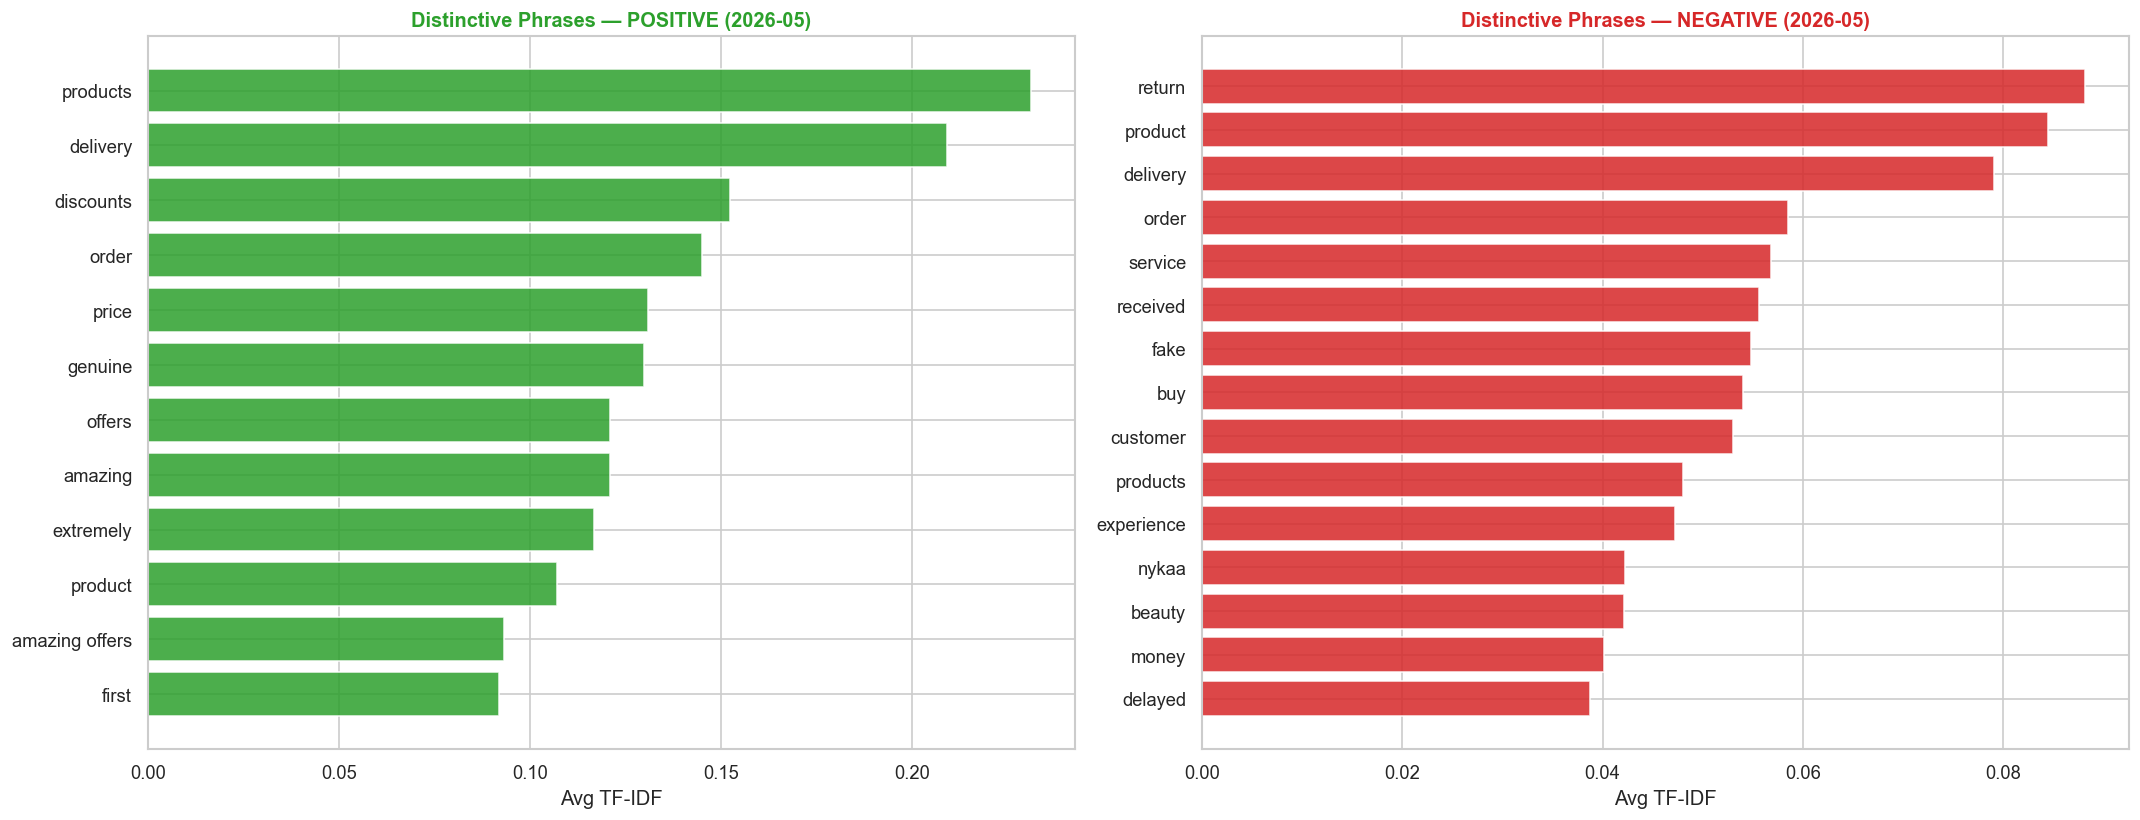

Top NEGATIVE phrases in 2026-05:
  return                         0.0881
  product                        0.0845
  delivery                       0.0791
  order                          0.0585
  service                        0.0568
  received                       0.0556
  fake                           0.0548
  buy                            0.0540
  customer                       0.0530
  products                       0.0480

Top POSITIVE phrases in 2026-05:
  products                       0.2311
  delivery                       0.2091
  discounts                      0.1524
  order                          0.1450
  price                          0.1308
  genuine                        0.1299
  offers                         0.1209
  amazing                        0.1209
  extremely                      0.1169
  product                        0.1070


In [9]:
def top_tfidf(texts, top_n=15):
    if len(texts) < 5: return []
    tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=2)
    mat = tfidf.fit_transform(texts)
    feat = np.array(tfidf.get_feature_names_out())
    mean_scores = mat.mean(axis=0).A1
    top_idx = mean_scores.argsort()[-top_n:][::-1]
    return list(zip(feat[top_idx], mean_scores[top_idx]))

neg_tfidf = top_tfidf(lat_neg['clean_body'].tolist())
pos_tfidf = top_tfidf(lat_pos['clean_body'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
if pos_tfidf:
    pw, pv = zip(*pos_tfidf)
    axes[0].barh(list(pw)[::-1], list(pv)[::-1], color='#2ca02c', edgecolor='white', alpha=0.85)
    axes[0].set_title(f'Distinctive Phrases — POSITIVE ({latest_month})', fontsize=12, fontweight='bold', color='#2ca02c')
    axes[0].set_xlabel('Avg TF-IDF')
if neg_tfidf:
    nw, nv = zip(*neg_tfidf)
    axes[1].barh(list(nw)[::-1], list(nv)[::-1], color='#d62728', edgecolor='white', alpha=0.85)
    axes[1].set_title(f'Distinctive Phrases — NEGATIVE ({latest_month})', fontsize=12, fontweight='bold', color='#d62728')
    axes[1].set_xlabel('Avg TF-IDF')
plt.tight_layout()
plt.savefig('r07_tfidf_latest.png', bbox_inches='tight')
plt.show()

print(f'Top NEGATIVE phrases in {latest_month}:')
for p, s in (neg_tfidf[:10] if neg_tfidf else []):
    print(f'  {p:<30} {s:.4f}')
print(f'\nTop POSITIVE phrases in {latest_month}:')
for p, s in (pos_tfidf[:10] if pos_tfidf else []):
    print(f'  {p:<30} {s:.4f}')

## 9. Sample Reviews — Latest Month

In [10]:
top_neg_themes = neg_tc[neg_tc.index!='Other'].head(5).index.tolist()
top_pos_themes = pos_tc[pos_tc.index!='Other'].head(3).index.tolist()

print('='*70)
print(f'{latest_month} — TOP NEGATIVE REVIEW SAMPLES')
print('='*70)
for theme in top_neg_themes:
    sub = lat_neg[lat_neg['themes'].apply(lambda x: theme in x)].nlargest(2, 'word_count')
    print(f'\n--- {theme.upper()} ---')
    for _, row in sub.iterrows():
        print(f'  [Rating {row.rating}] {str(row.body)[:280]}')

print('\n'+'='*70)
print(f'{latest_month} — TOP POSITIVE REVIEW SAMPLES')
print('='*70)
for theme in top_pos_themes:
    sub = lat_pos[lat_pos['themes'].apply(lambda x: theme in x)].nlargest(2, 'word_count')
    print(f'\n--- {theme.upper()} ---')
    for _, row in sub.iterrows():
        print(f'  [Rating {row.rating}] {str(row.body)[:280]}')

2026-05 — TOP NEGATIVE REVIEW SAMPLES

--- CUSTOMER SUPPORT ---
  [Rating 1] Extremely disappointed with Tira's abysmal customer service and deceitful practices. Despite being a returning customer, my experience has been frustrating. They have a terrible policy of refusing to cancel orders, even when wrong items are received. Recently, an item was complet
  [Rating 1] Tira Beauty￼ really fools its customer base. If you order a product and later want to return it, you may not be able to because they don’t even provide a proper return option like other beauty platforms such as Nykaa￼ and Myntra￼ do.

I mistakenly ordered the 80ml version of the 

--- PRODUCT QUALITY ---
  [Rating 1] I recently purchased a Clinique face cream worth 4600 Rs. they have forcefully sent me a product just about 6 months left for expiration . The box has no seal and the box is torn and soiled with dust as it was shelved for 2 entire years, with only 6 months left for it to be expir
  [Rating 1] Extremely disapp

## 10. Executive Summary — Recent Period

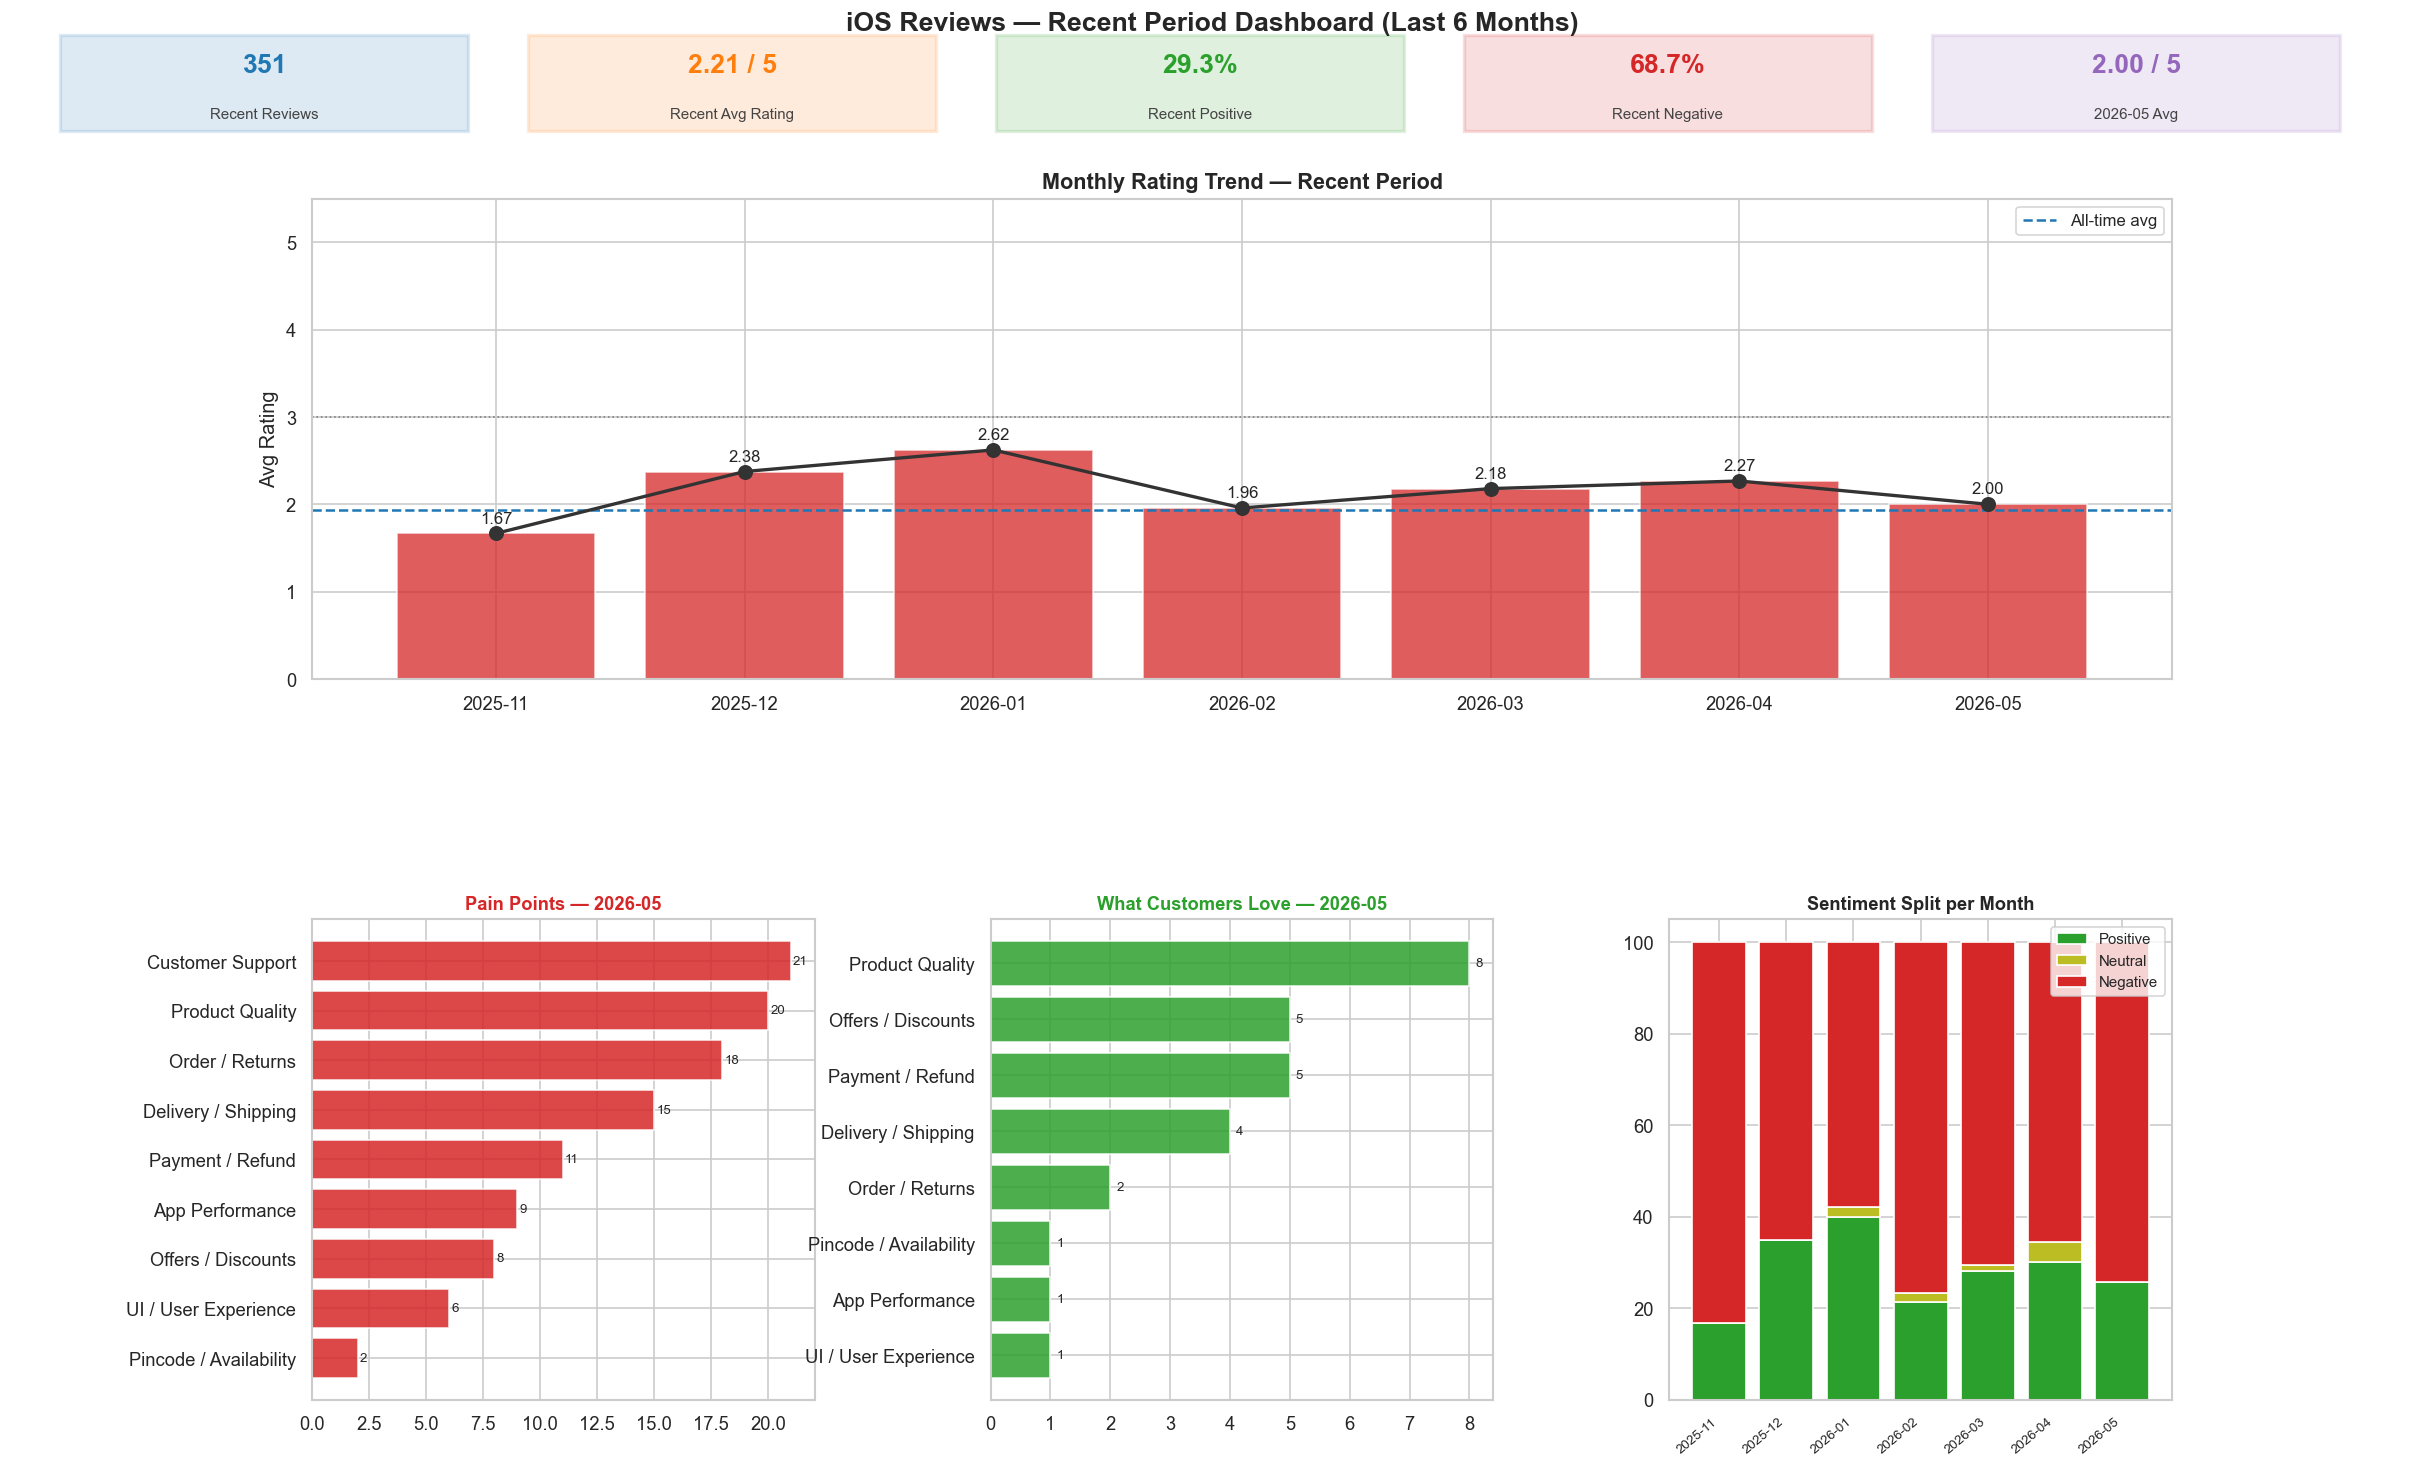

     KEY TAKEAWAYS — iOS RECENT PERIOD
Period         : 2025-11-21 to 2026-05-18
Reviews        : 351  |  Avg Rating: 2.21
Positive       : 29.3%  |  Negative: 68.7%
Trend          : IMPROVING
Best Month     : 2026-01 (avg 2.62)
Worst Month    : 2025-11 (avg 1.67)

Top Pain Points in 2026-05:
  Customer Support              21 (72.4%)
  Product Quality               20 (69.0%)
  Order / Returns               18 (62.1%)
  Delivery / Shipping           15 (51.7%)
  Payment / Refund              11 (37.9%)

What Customers Love in 2026-05:
  Product Quality                8 (80.0%)
  Payment / Refund               5 (50.0%)
  Offers / Discounts             5 (50.0%)
  Delivery / Shipping            4 (40.0%)
  Order / Returns                2 (20.0%)


In [11]:
fig = plt.figure(figsize=(20, 13))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35)

kpi_ax = fig.add_axes([0, 0.92, 1, 0.07])
kpi_ax.axis('off')
kpi_items = [
    ('Recent Reviews',   f'{len(df):,}',                         '#1f77b4'),
    ('Recent Avg Rating',f'{df["rating"].mean():.2f} / 5',       '#ff7f0e'),
    ('Recent Positive',  f'{sp_rec.get("Positive",0):.1f}%',     '#2ca02c'),
    ('Recent Negative',  f'{sp_rec.get("Negative",0):.1f}%',     '#d62728'),
    (f'{latest_month} Avg', f'{latest_df["rating"].mean():.2f} / 5', '#9467bd'),
]
for i, (label, val, color) in enumerate(kpi_items):
    x = 0.02 + i*0.195
    kpi_ax.add_patch(plt.Rectangle((x,0.05), 0.17, 0.88, transform=kpi_ax.transAxes,
                                    color=color, alpha=0.15, linewidth=2, edgecolor=color))
    kpi_ax.text(x+0.085, 0.65, val, ha='center', va='center', fontsize=16,
                fontweight='bold', color=color, transform=kpi_ax.transAxes)
    kpi_ax.text(x+0.085, 0.2, label, ha='center', va='center', fontsize=9,
                color='#444', transform=kpi_ax.transAxes)

# Monthly rating trend
ax1 = fig.add_subplot(gs[0,:])
bc_m = ['#2ca02c' if r>=4 else '#ff7f0e' if r>=3 else '#d62728' for r in monthly['avg_rating']]
ax1.bar(range(len(monthly)), monthly['avg_rating'], color=bc_m, edgecolor='white', alpha=0.75)
ax1.plot(range(len(monthly)), monthly['avg_rating'], 'o-', color='#333', linewidth=2, markersize=8, zorder=5)
ax1.axhline(df_all['rating'].mean(), color='#1f77b4', linestyle='--', linewidth=1.5, label=f'All-time avg')
ax1.axhline(3, color='gray', linestyle=':', linewidth=1)
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly['year_month'].tolist(), fontsize=11)
ax1.set_ylim(0, 5.5); ax1.set_ylabel('Avg Rating')
ax1.set_title('Monthly Rating Trend — Recent Period', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
for xi,(_, row) in enumerate(monthly.iterrows()):
    ax1.text(xi, row['avg_rating']+0.12, f"{row['avg_rating']:.2f}", ha='center', fontsize=10)

# Pain points latest month
ax2 = fig.add_subplot(gs[1,0])
nc_d = neg_tc[neg_tc.index!='Other'].sort_values(ascending=True)
ax2.barh(nc_d.index, nc_d.values, color='#d62728', edgecolor='white', alpha=0.85)
ax2.set_title(f'Pain Points — {latest_month}', fontsize=11, fontweight='bold', color='#d62728')
for i,v in enumerate(nc_d.values):
    ax2.text(v+0.1, i, str(v), va='center', fontsize=8)

# What customers love
ax3 = fig.add_subplot(gs[1,1])
pc_d = pos_tc[pos_tc.index!='Other'].sort_values(ascending=True)
ax3.barh(pc_d.index, pc_d.values, color='#2ca02c', edgecolor='white', alpha=0.85)
ax3.set_title(f'What Customers Love — {latest_month}', fontsize=11, fontweight='bold', color='#2ca02c')
for i,v in enumerate(pc_d.values):
    ax3.text(v+0.1, i, str(v), va='center', fontsize=8)

# Sentiment stacked
ax4 = fig.add_subplot(gs[1,2])
xv = range(len(monthly))
ax4.bar(xv, monthly['pct_pos'], label='Positive', color='#2ca02c', edgecolor='white')
ax4.bar(xv, monthly['pct_neu'], bottom=monthly['pct_pos'], label='Neutral', color='#bcbd22', edgecolor='white')
ax4.bar(xv, monthly['pct_neg'], bottom=monthly['pct_pos']+monthly['pct_neu'], label='Negative', color='#d62728', edgecolor='white')
ax4.set_xticks(list(xv))
ax4.set_xticklabels(monthly['year_month'].tolist(), rotation=40, ha='right', fontsize=8)
ax4.set_title('Sentiment Split per Month', fontsize=11, fontweight='bold')
ax4.legend(fontsize=9)

fig.suptitle('iOS Reviews — Recent Period Dashboard (Last 6 Months)', fontsize=16, fontweight='bold', y=1.0)
plt.savefig('r00_recent_dashboard.png', bbox_inches='tight', dpi=130)
plt.show()

# Final summary
rec_trend = 'IMPROVING' if monthly.iloc[-1]['avg_rating'] > monthly.iloc[0]['avg_rating'] else 'DECLINING'
print('='*60)
print('     KEY TAKEAWAYS — iOS RECENT PERIOD')
print('='*60)
print(f'Period         : {df["created_date"].min().date()} to {df["created_date"].max().date()}')
print(f'Reviews        : {len(df):,}  |  Avg Rating: {df["rating"].mean():.2f}')
print(f'Positive       : {sp_rec.get("Positive",0):.1f}%  |  Negative: {sp_rec.get("Negative",0):.1f}%')
print(f'Trend          : {rec_trend}')
print(f'Best Month     : {monthly.nlargest(1,"avg_rating").iloc[0]["year_month"]} (avg {monthly.nlargest(1,"avg_rating").iloc[0]["avg_rating"]:.2f})')
print(f'Worst Month    : {monthly.nsmallest(1,"avg_rating").iloc[0]["year_month"]} (avg {monthly.nsmallest(1,"avg_rating").iloc[0]["avg_rating"]:.2f})')
print(f'\nTop Pain Points in {latest_month}:')
for t,c in neg_tc[neg_tc.index!='Other'].head(5).items():
    print(f'  {t:<28} {c:>3} ({c/max(len(lat_neg),1)*100:.1f}%)')
print(f'\nWhat Customers Love in {latest_month}:')
for t,c in pos_tc[pos_tc.index!='Other'].head(5).items():
    print(f'  {t:<28} {c:>3} ({c/max(len(lat_pos),1)*100:.1f}%)')
print('='*60)